In [1]:
# Imports
import time
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hysys import open_case, cache_objects, run_point, dump, members
import hysys

In [2]:
# Setup
CASE = r"C:\Users\kr326\Documents\Andrea_Files_MeOH_Aspen\TestAspenFile\methanol.hsc"
t0 = time.time()
case = open_case(CASE)

print(f"Case name:        {case.Name}")
print(f"Material streams: {case.Flowsheet.MaterialStreams.Count}")
print(f"Connected in      {time.time() - t0:.1f} s")

# Cache flowsheet objects
objects = cache_objects(case)
print("Objects cached OK:")
for k in objects:
    print(f"  {k}")

Case not open in HYSYS - launching (this can take a minute)...
Case name:        Case
Material streams: 42
Connected in      11.8 s
Objects cached OK:
  solver
  units
  co2in
  h2in
  rin
  rout
  methanol
  purge
  recycle_gas
  reactor
  split
  column
  flare
  recycle
  pressure_cell
  ratio_cell
  h2_index
  co2_index
  meoh_index


In [3]:
def p_T_sweep():
    results = []
    all_temp = np.linspace(220, 280, 20) # [C]
    all_press = np.linspace(70, 120, 20) # [bar]

    for T, P in itertools.product(all_temp, all_press):
        print("procesing", "T", T, "P", P)
        point = dict(temperature=(T, "C"), pressure=(P, "bar"))
        results.append(run_point(objects, **point))

    return results
results = p_T_sweep()

procesing T 220.0 P 70.0
procesing T 220.0 P 72.63157894736842
procesing T 220.0 P 75.26315789473685
procesing T 220.0 P 77.89473684210526
procesing T 220.0 P 80.52631578947368
procesing T 220.0 P 83.15789473684211
procesing T 220.0 P 85.78947368421052
procesing T 220.0 P 88.42105263157895
procesing T 220.0 P 91.05263157894737
procesing T 220.0 P 93.6842105263158
procesing T 220.0 P 96.31578947368422
procesing T 220.0 P 98.94736842105263
procesing T 220.0 P 101.57894736842105
procesing T 220.0 P 104.21052631578948
procesing T 220.0 P 106.84210526315789
procesing T 220.0 P 109.47368421052632
procesing T 220.0 P 112.10526315789474
procesing T 220.0 P 114.73684210526316
procesing T 220.0 P 117.36842105263159
procesing T 220.0 P 120.0
procesing T 223.1578947368421 P 70.0
procesing T 223.1578947368421 P 72.63157894736842
procesing T 223.1578947368421 P 75.26315789473685
procesing T 223.1578947368421 P 77.89473684210526
procesing T 223.1578947368421 P 80.52631578947368
procesing T 223.157894

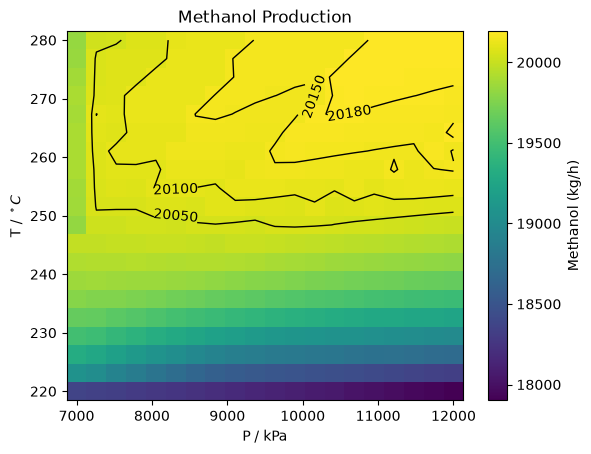

In [4]:
# df.plot.scatter(x="pressure_set", y="temperature_set", c="methanol_kg_h", colormap="viridis", s=60)
df = pd.DataFrame(results)
def methanol_heatmap():
    grid = df.pivot(index="temperature_set", columns="pressure_set", values="methanol_kg_h")

    fig, ax = plt.subplots(1, 1)
    mesh = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap="viridis", shading="nearest")
    cs = ax.contour(grid.columns, grid.index, grid.values, levels=[20050, 20100, 20150, 20180], colors="black", linewidths=1)
    ax.clabel(cs, fmt="%.0f")
    ax.set_xlabel("P / kPa")
    ax.set_ylabel("T / $^\\circ{C}$")
    ax.set_title("Methanol Production")
    fig.colorbar(mesh, ax=ax, label="Methanol (kg/h)")

methanol_heatmap()

In [11]:
df["recycle_ratio"].max()
df["recycle_ratio"].min()

np.float64(13.522412287124425)

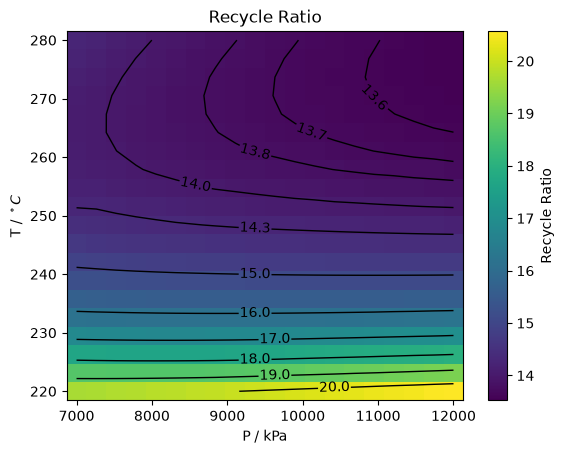

In [19]:
def recycle_ratio_heatmap():
    grid = df.pivot(index="temperature_set", columns="pressure_set", values="recycle_ratio")
    fig, ax = plt.subplots(1, 1)
    mesh = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap="viridis", shading="nearest")
    cs = ax.contour(grid.columns, grid.index, grid.values, levels=[13.6, 13.7, 13.8, 14, 14.3, 15, 16, 17, 18, 19, 20], colors="black", linewidths=1)
    ax.clabel(cs, fmt="%.1f")
    ax.set_xlabel("P / kPa")
    ax.set_ylabel("T / $^\\circ{C}$")
    ax.set_title("Recycle Ratio")
    fig.colorbar(mesh, ax=ax, label="Recycle Ratio")

recycle_ratio_heatmap()

In [ ]:
def pressure_drop_heatmap():
    # grid = df.pivot(index="temperature_set", columns="pressure_set", values="methanol_kg_h")

    # fig, ax = plt.subplots(1, 1)
    # mesh = ax.pcolormesh(grid.columns, grid.index, grid.values, cmap="viridis", shading="nearest")
    # cs = ax.contour(grid.columns, grid.index, grid.values, levels=[20050, 20100, 20150, 20180], colors="black", linewidths=1)
    # ax.clabel(cs, fmt="%.0f")
    # ax.set_xlabel("P / kPa")
    # ax.set_ylabel("T / $^\\circ{C}$")
    # ax.set_title("Methanol Production")
    # fig.colorbar(mesh, ax=ax, label="Methanol (kg/h)")

pressure_drop_heatmap()

# TODO:
> Fix pressure (e.g. 90 bar), vary the temperature (we want the local maximum, so perhaps higher bound, say 220-300 or even 320)
> Vary additionally the purge rate to have two opposing effects (with regards to the constraints)